Deep learning for stage prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, f1_score, 
                             precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import shap

# Load data
data_filtered = pd.read_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\transposed_data.csv')

# Display the new DataFrame
print(data_transposed)

NameError: name 'data_transposed' is not defined

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 573ms/step - AUC: 0.7790 - loss: 4.1610 - val_AUC: 0.0000e+00 - val_loss: 1.0354e-07
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 566ms/step - AUC: 1.0000 - loss: 0.0013 - val_AUC: 0.0000e+00 - val_loss: 5.2625e-08
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 569ms/step - AUC: 1.0000 - loss: 8.0958e-06 - val_AUC: 0.0000e+00 - val_loss: 4.3372e-08
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 561ms/step - AUC: 1.0000 - loss: 7.1179e-05 - val_AUC: 0.0000e+00 - val_loss: 3.6324e-08
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 562ms/step - AUC: 1.0000 - loss: 2.2480e-04 - val_AUC: 0.0000e+00 - val_loss: 3.6598e-08
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 565ms/step - AUC: 1.0000 - loss: 1.2924e-05 - val_AUC: 0.0000e+00 - val_loss: 2.7134e-08
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 575ms/step - AUC: 1.0000 - loss: 1.3016e-05 - val_AUC: 0.0000e+00 - val_loss: 2.1601e-08
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 586ms/step - AUC: 1.0000 - loss: 1.4508e-

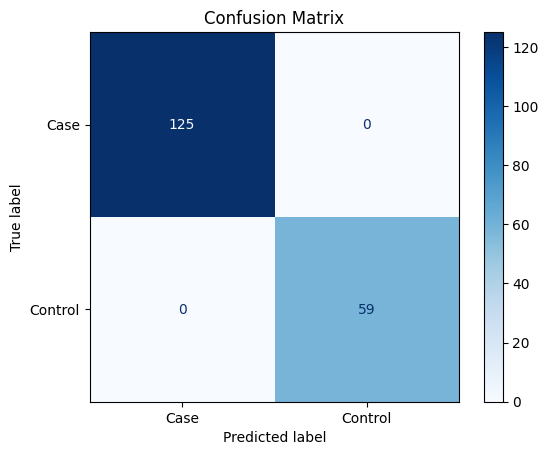

Provided model function fails when applied to the provided data set.


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

In [16]:
target="label"
X = data_filtered.drop([target], axis=1)  # Drop target variable
y = data_filtered[target]

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Reshape data for CNN input
X_resampled = np.expand_dims(X_resampled, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# Compute class weights
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# Build the CNN model
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_resampled.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))
model.add(Conv1D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Train the model
history = model.fit(X_resampled, y_resampled, epochs=100, batch_size=16, validation_split=0.2, class_weight=class_weights)

# Evaluate the model
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()  # Use threshold for binary classification
y_test_labels = y_test  # No need for argmax since y_test is 1D

# Calculate evaluation metrics
auc_score = roc_auc_score(y_test_labels, y_pred_proba)
f1 = f1_score(y_test_labels, y_pred)
precision = precision_score(y_test_labels, y_pred)
recall = recall_score(y_test_labels, y_pred)

# Display results
print(f"AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Show confusion matrix
cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


# SHAP summary plots (KernelExplainer for neural networks)
explainer = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (beeswarm)
plt.figure(figsize=(15, 10))  # Increase the plot size
shap.summary_plot(shap_values, X_test)

# Determine the top 100 most important features based on SHAP values
shap_importances = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X.columns, 'importance': shap_importances})
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100)

# Save the top 100 features to a CSV file
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_top_100_shap_features.csv', index=False)
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'")

# Plot top 100 most important features
plt.figure(figsize=(12, 20))  # Increase the plot size
sns.barplot(x='importance', y='feature', data=shap_importance_df)
plt.title('Top 100 Most Important Features')
plt.xlabel('SHAP Importance')
plt.ylabel('Feature')
plt.show()


Catboost for stage presictin

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, matthews_corrcoef, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from catboost import CatBoostClassifier
import shap
target="label"
# Load data
data_filtered = pd.read_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\transposed_data.csv')

# Step 1: Prepare features and target variable
X = data_filtered.drop([target], axis=1)  # Drop target variable
y = data_filtered[target]

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Visualize class distribution after KMeans-SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='Set2')
plt.title('Class Distribution after KMeans-SMOTE')
plt.xlabel('Stage Group')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.show()

# Define parameter grid for CatBoost
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8]
}

# Initialize GridSearchCV with focus on F1 score for minority class
grid_search = GridSearchCV(estimator=CatBoostClassifier(random_state=42, verbose=0),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_resampled, y_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("Best CatBoost Classifier Performance:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Compute AUC score
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f'AUC: {auc_best:.2f}')

# Calculate additional metrics
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient (MCC): {mcc:.2f}')

# Plot ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(fpr_best, tpr_best, color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best CatBoost Classifier')
plt.show()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best CatBoost Classifier')
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', color='blue', label='CatBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot - Best CatBoost Classifier')
plt.legend()
plt.show()

# SHAP summary plots
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot (beeswarm)
plt.figure(figsize=(15, 10))  # Increase the plot size
shap.summary_plot(shap_values, X_test)

# Determine the top 100 most important features based on SHAP values
shap_importances = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances})
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100)

# Save the top 100 features to a CSV file
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_top_100_shap_features.csv', index=False)
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'")

# Plot top 100 most important features
plt.figure(figsize=(12, 20))  # Increase the plot size
sns.barplot(x='importance', y='feature', data=shap_importance_df)
plt.title('Top 100 Most Important Features')
plt.xlabel('SHAP Importance')
plt.ylabel('Feature')
plt.show()


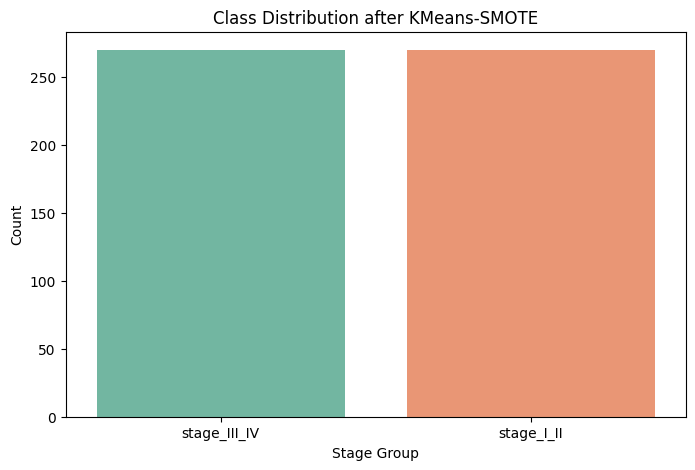

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'depth': 6, 'iterations': 100, 'learning_rate': 0.2}
Best CatBoost Classifier Performance:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       116
           1       1.00      0.43      0.60         7

    accuracy                           0.97       123
   macro avg       0.98      0.71      0.79       123
weighted avg       0.97      0.97      0.96       123

Confusion Matrix:
[[116   0]
 [  4   3]]
AUC: 0.86
Matthews Correlation Coefficient (MCC): 0.64


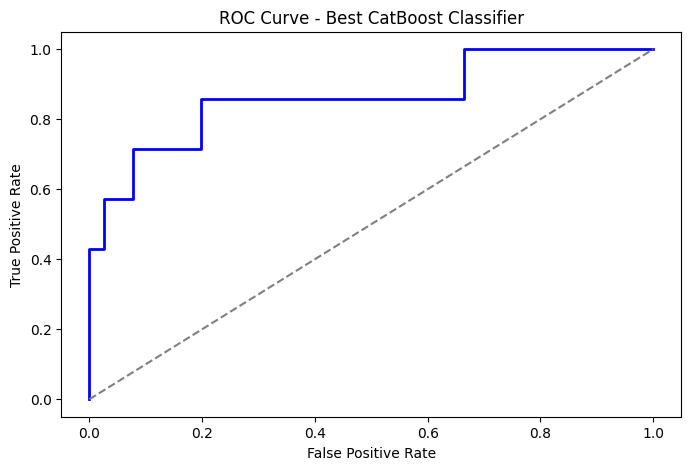

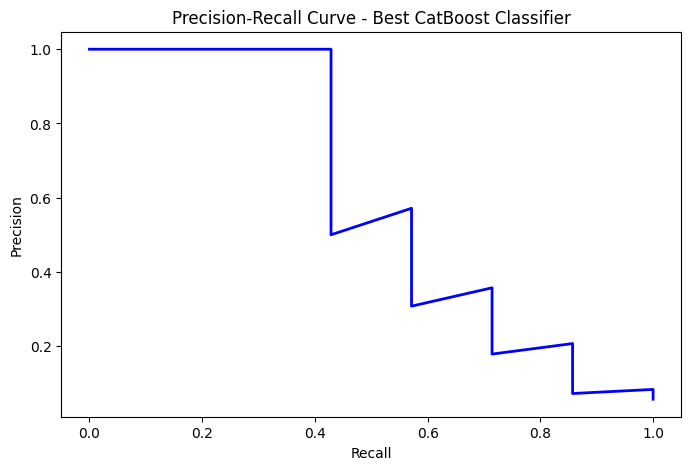

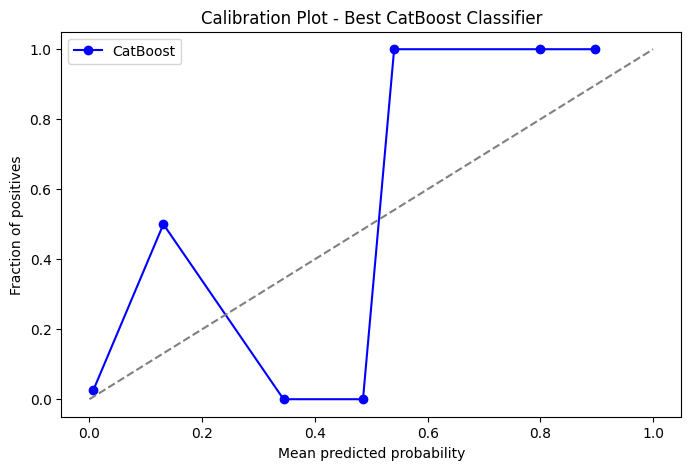

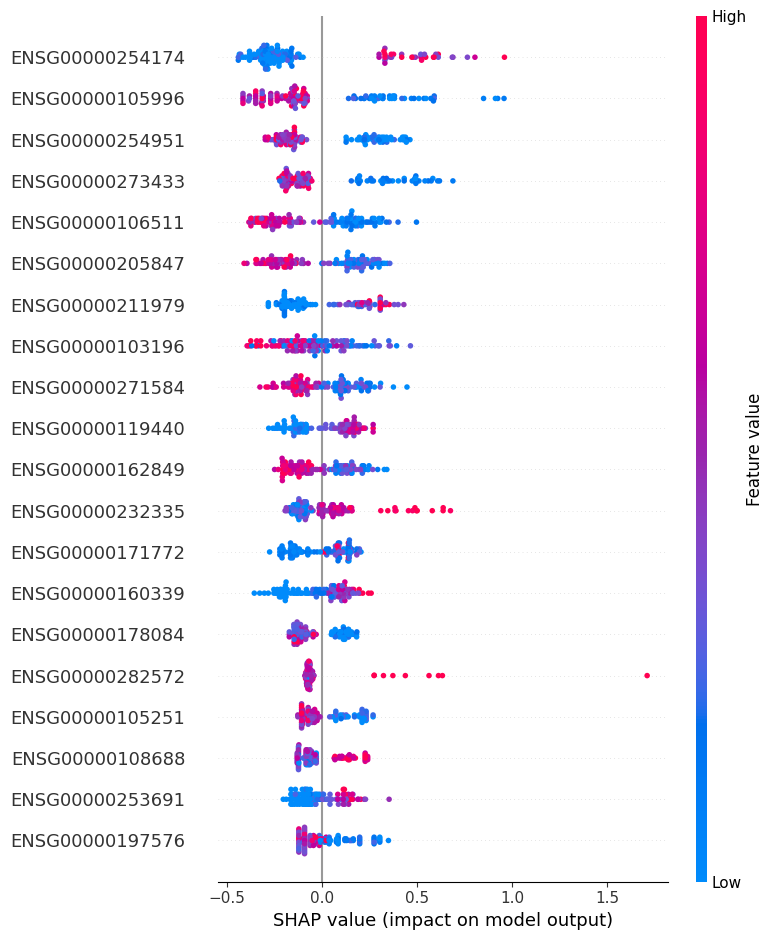

Top 100 most important features saved to 'top_100_shap_features.csv'


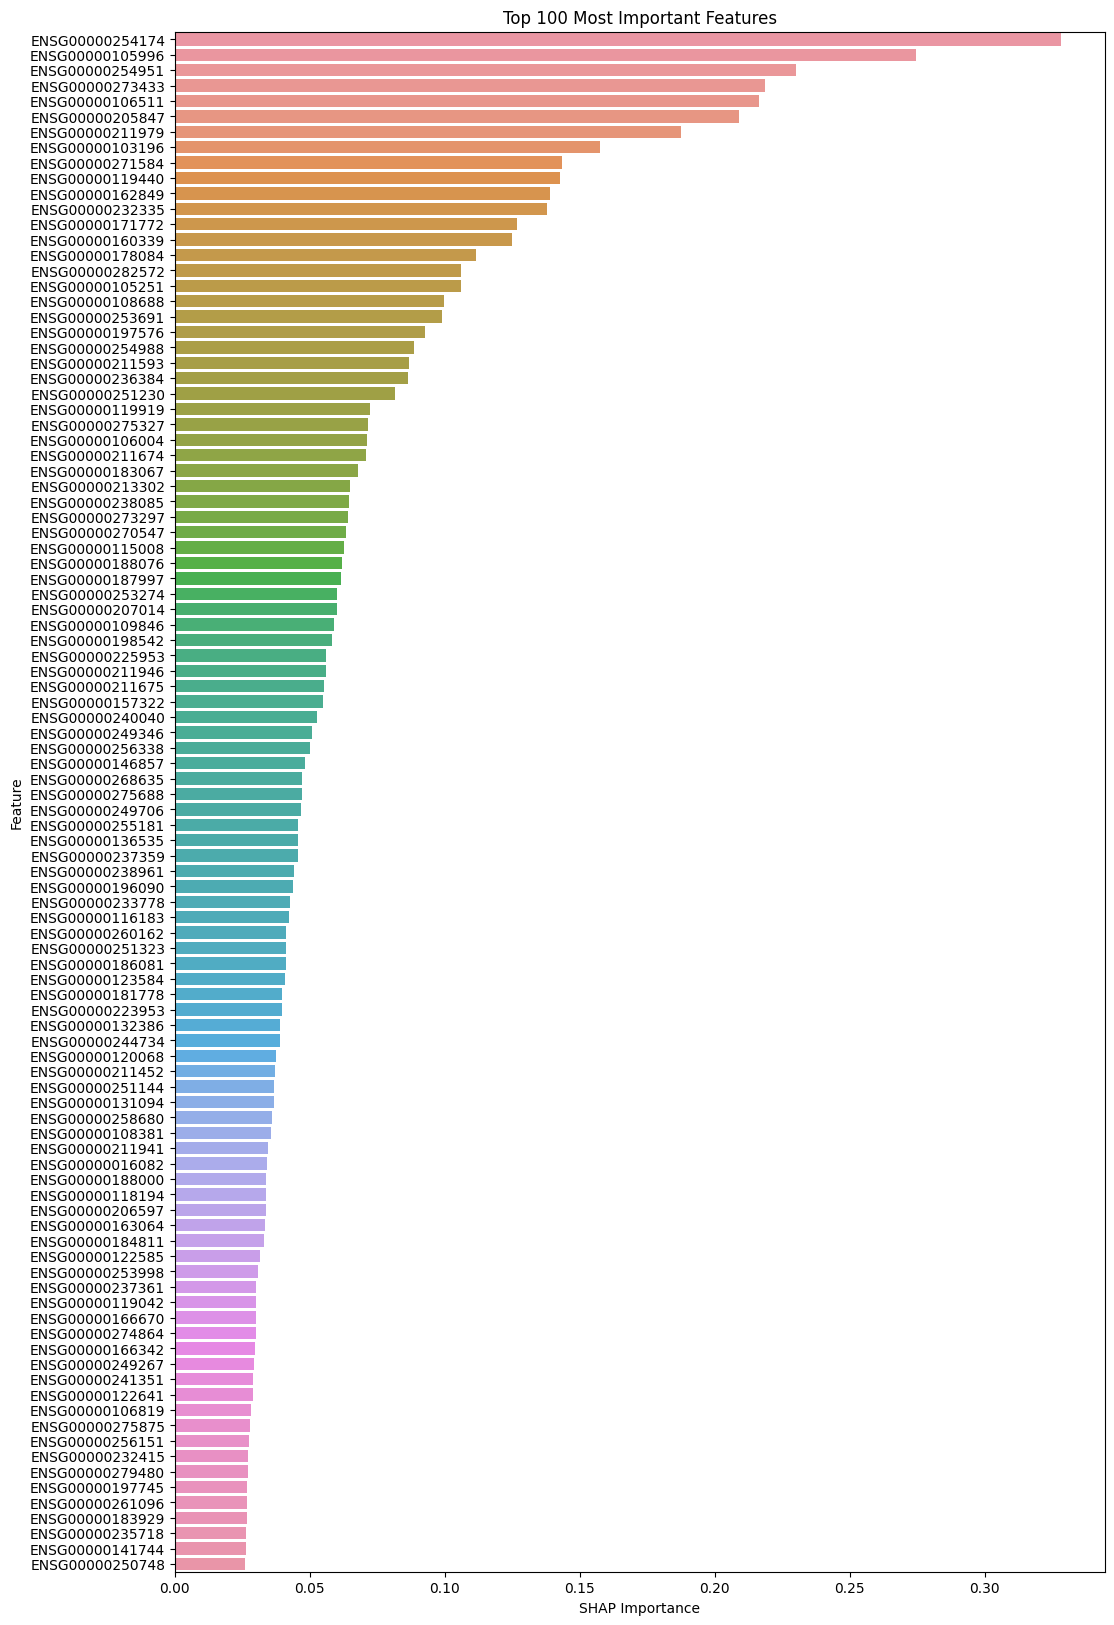

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, matthews_corrcoef, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from catboost import CatBoostClassifier
import shap

# Load data
data_filtered = pd.read_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\transposed_data.csv')

# Step 1: Prepare features and target variable
X = data_filtered.drop([target], axis=1)  # Drop target variable
y = data_filtered[target]

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop([target], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Visualize class distribution after KMeans-SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='Set2')
plt.title('Class Distribution after KMeans-SMOTE')
plt.xlabel('Stage Group')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_class_distribution_kmeans_smote.png')  # Save image
plt.show()

# Define parameter grid for CatBoost
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8]
}

# Initialize GridSearchCV with focus on F1 score for minority class
grid_search = GridSearchCV(estimator=CatBoostClassifier(random_state=42, verbose=0),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_resampled, y_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("Best CatBoost Classifier Performance:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Compute AUC score
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f'AUC: {auc_best:.2f}')

# Calculate additional metrics
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient (MCC): {mcc:.2f}')

# Plot ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(fpr_best, tpr_best, color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best CatBoost Classifier')
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_roc_curve_best_catboost.png')  # Save image
plt.show()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best CatBoost Classifier')
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_precision_recall_curve_best_catboost.png')  # Save image
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', color='blue', label='CatBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot - Best CatBoost Classifier')
plt.legend()
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_calibration_plot_best_catboost.png')  # Save image
plt.show()

# SHAP summary plots
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot (beeswarm)
plt.figure(figsize=(15, 10))  # Increase the plot size
shap.summary_plot(shap_values, X_test, show=False)  # Prevents auto-showing
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_shap_summary_plot.png')  # Save image
plt.show()

# Determine the top 100 most important features based on SHAP values
shap_importances = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances})
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100)

# Save the top 100 features to a CSV file
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_top_100_shap_features.csv', index=False)
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'")

# Plot top 100 most important features
plt.figure(figsize=(12, 20))  # Increase the plot size
sns.barplot(x='importance', y='feature', data=shap_importance_df)
plt.title('Top 100 Most Important Features')
plt.xlabel('SHAP Importance')
plt.ylabel('Feature')
plt.savefig('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\all case and control_top_100_features_plot.png')  # Save image
plt.show()


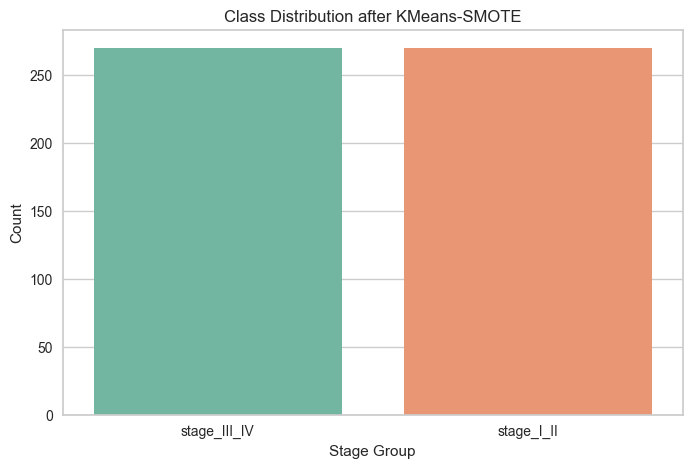

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5}
Best XGBoost Classifier Performance:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       116
           1       0.60      0.43      0.50         7

    accuracy                           0.95       123
   macro avg       0.78      0.71      0.74       123
weighted avg       0.95      0.95      0.95       123

Confusion Matrix:
[[114   2]
 [  4   3]]
AUC: 0.89
Matthews Correlation Coefficient (MCC): 0.48


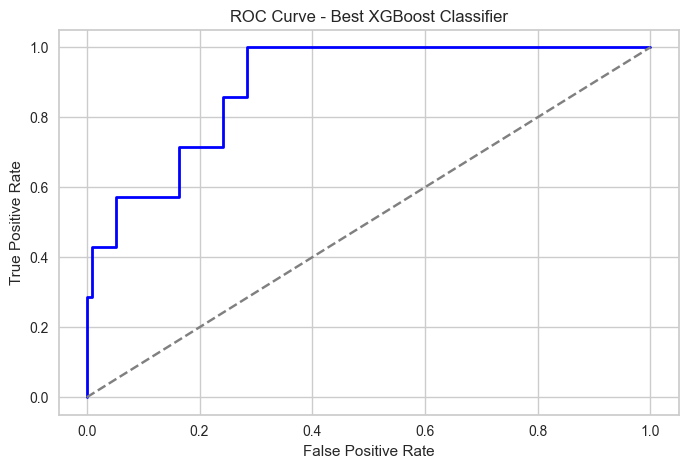

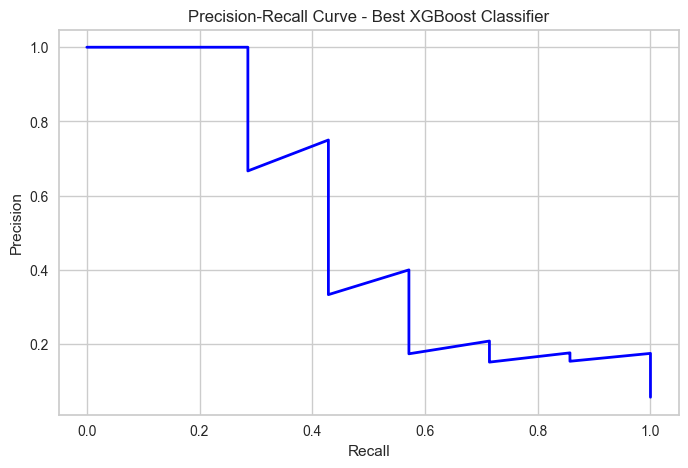

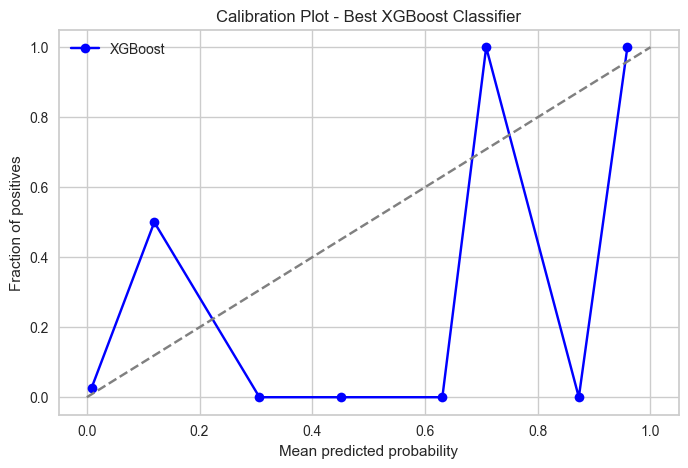

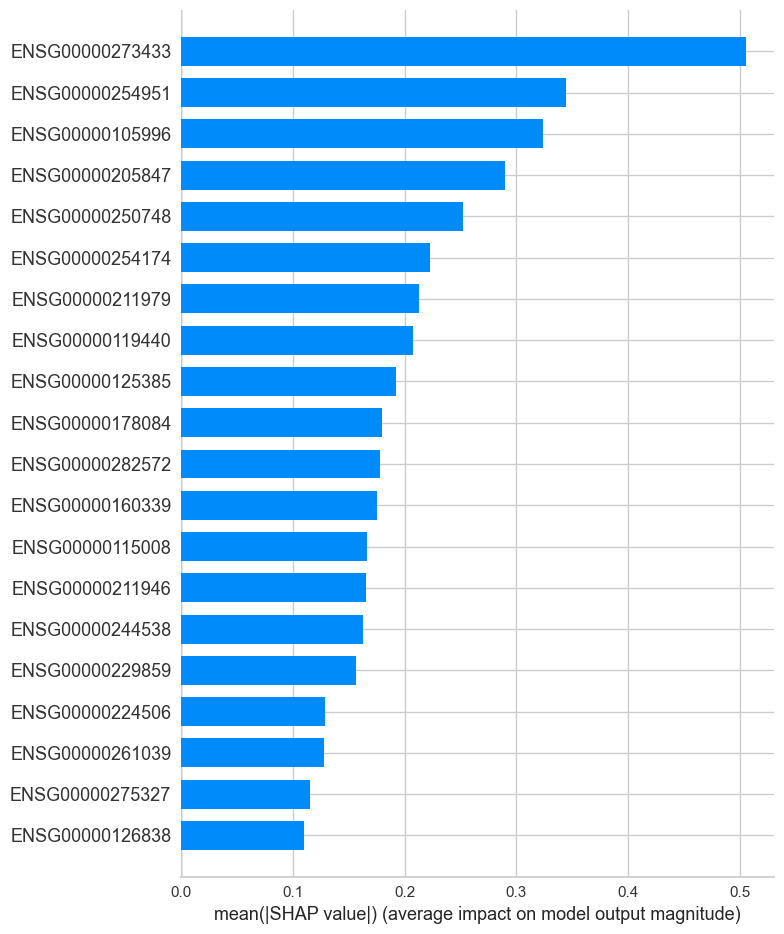

Top 100 most important features saved to 'top_100_shap_features.csv'


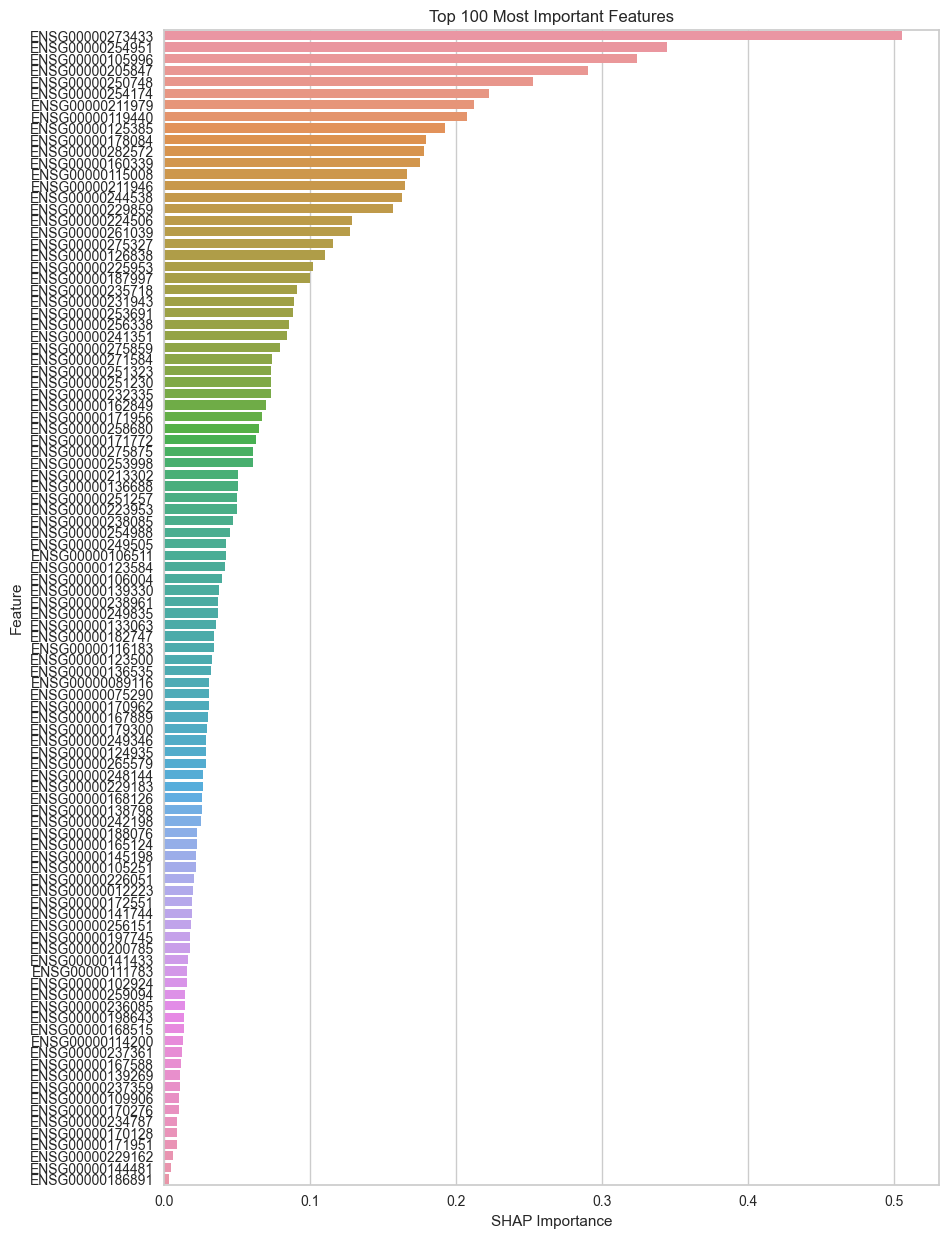

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import KMeansSMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, matthews_corrcoef, brier_score_loss, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBClassifier
import shap

# Load data
data_filtered = pd.read_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\transposed_data.csv')

# Step 1: Prepare features and target variable
X = data_filtered.drop(['stage_group'], axis=1)  # Drop target variable
y = data_filtered['stage_group']

# Step 2: Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

# Convert back to DataFrame for easier handling
X = pd.DataFrame(X, columns=data_filtered.drop(['stage_group'], axis=1).columns[selector.get_support()])

# Step 3: Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=data_filtered.drop(['stage_group'], axis=1).columns[selector.get_support()])

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 5: Perform KMeans-SMOTE on the training set with adjusted parameters
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=42)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Visualize class distribution after KMeans-SMOTE
plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='Set2')
plt.title('Class Distribution after KMeans-SMOTE')
plt.xlabel('Stage Group')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.show()

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.2],
    'max_depth': [3, 5, 4],
    'scale_pos_weight': [4, 5, 8]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                           param_grid=param_grid,
                           cv=3,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X_resampled, y_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
print("Best XGBoost Classifier Performance:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Compute AUC score
auc_best = roc_auc_score(y_test, y_pred_proba_best)
print(f'AUC: {auc_best:.2f}')

# Calculate additional metrics
mcc = matthews_corrcoef(y_test, y_pred_best)
print(f'Matthews Correlation Coefficient (MCC): {mcc:.2f}')

# Plot ROC curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(fpr_best, tpr_best, color='blue', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best XGBoost Classifier')
plt.show()

# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best XGBoost Classifier')
plt.show()

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot(prob_pred, prob_true, marker='o', color='blue', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot - Best XGBoost Classifier')
plt.legend()
plt.show()

# SHAP summary plots
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Determine the top 100 most important features based on SHAP values
shap_importances = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances})
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100)

# Save the top 100 features to a CSV file
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\top_100_shap_features_vt.csv', index=False)
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'")

# Plot top 100 most important features
plt.figure(figsize=(10, 15))
sns.barplot(x='importance', y='feature', data=shap_importance_df)
plt.title('Top 100 Most Important Features')
plt.xlabel('SHAP Importance')
plt.ylabel('Feature')
plt.show()

# SHAP summary plots 
explainer = shap.Explainer(best_model, X_train) 
shap_values = explainer(X_test) 
plt.figure(figsize=(15, 10)) # Increase the plot size 
shap.summary_plot(shap_values, X_test) # Determine the top 100 most important features based on SHAP values 
shap_importances = np.abs(shap_values.values).mean(axis=0) 
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances}) 
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100) # Save the top 100 features to a CSV file 
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\top_100_shap_features_vt.csv', index=False) 
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'") # Plot top 100 most important features 
plt.figure(figsize=(12, 20)) # Increase the plot size 
sns.barplot(x='importance', y='feature', data=shap_importance_df) 
plt.title('Top 100 Most Important Features') 
plt.xlabel('SHAP Importance') 
plt.ylabel('Feature')
plt.show()


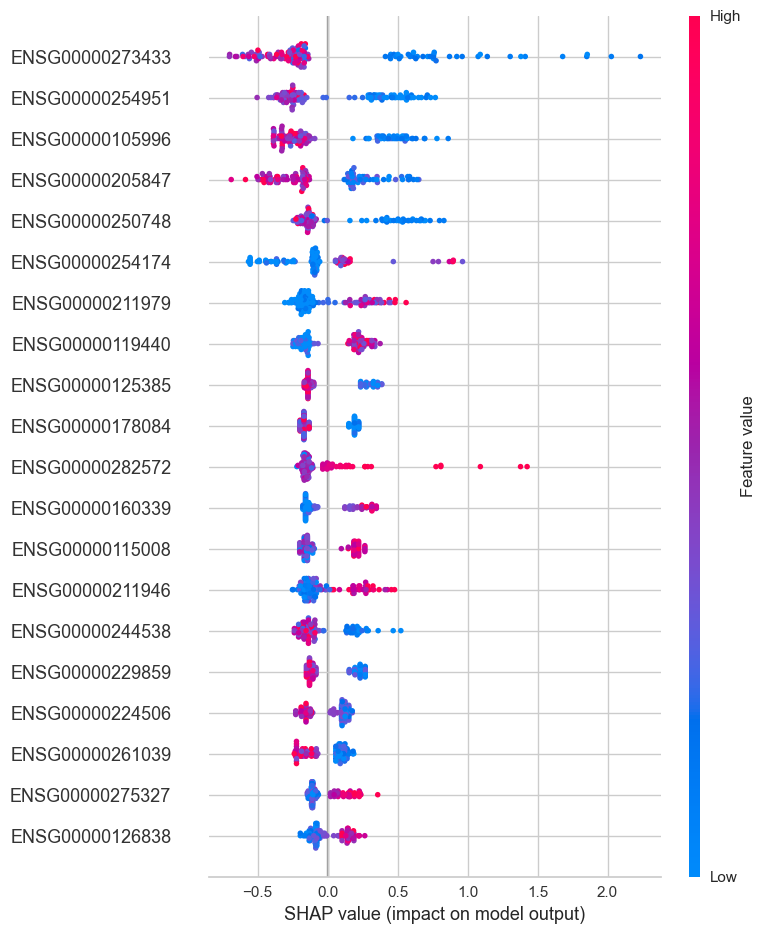

Top 100 most important features saved to 'top_100_shap_features.csv'


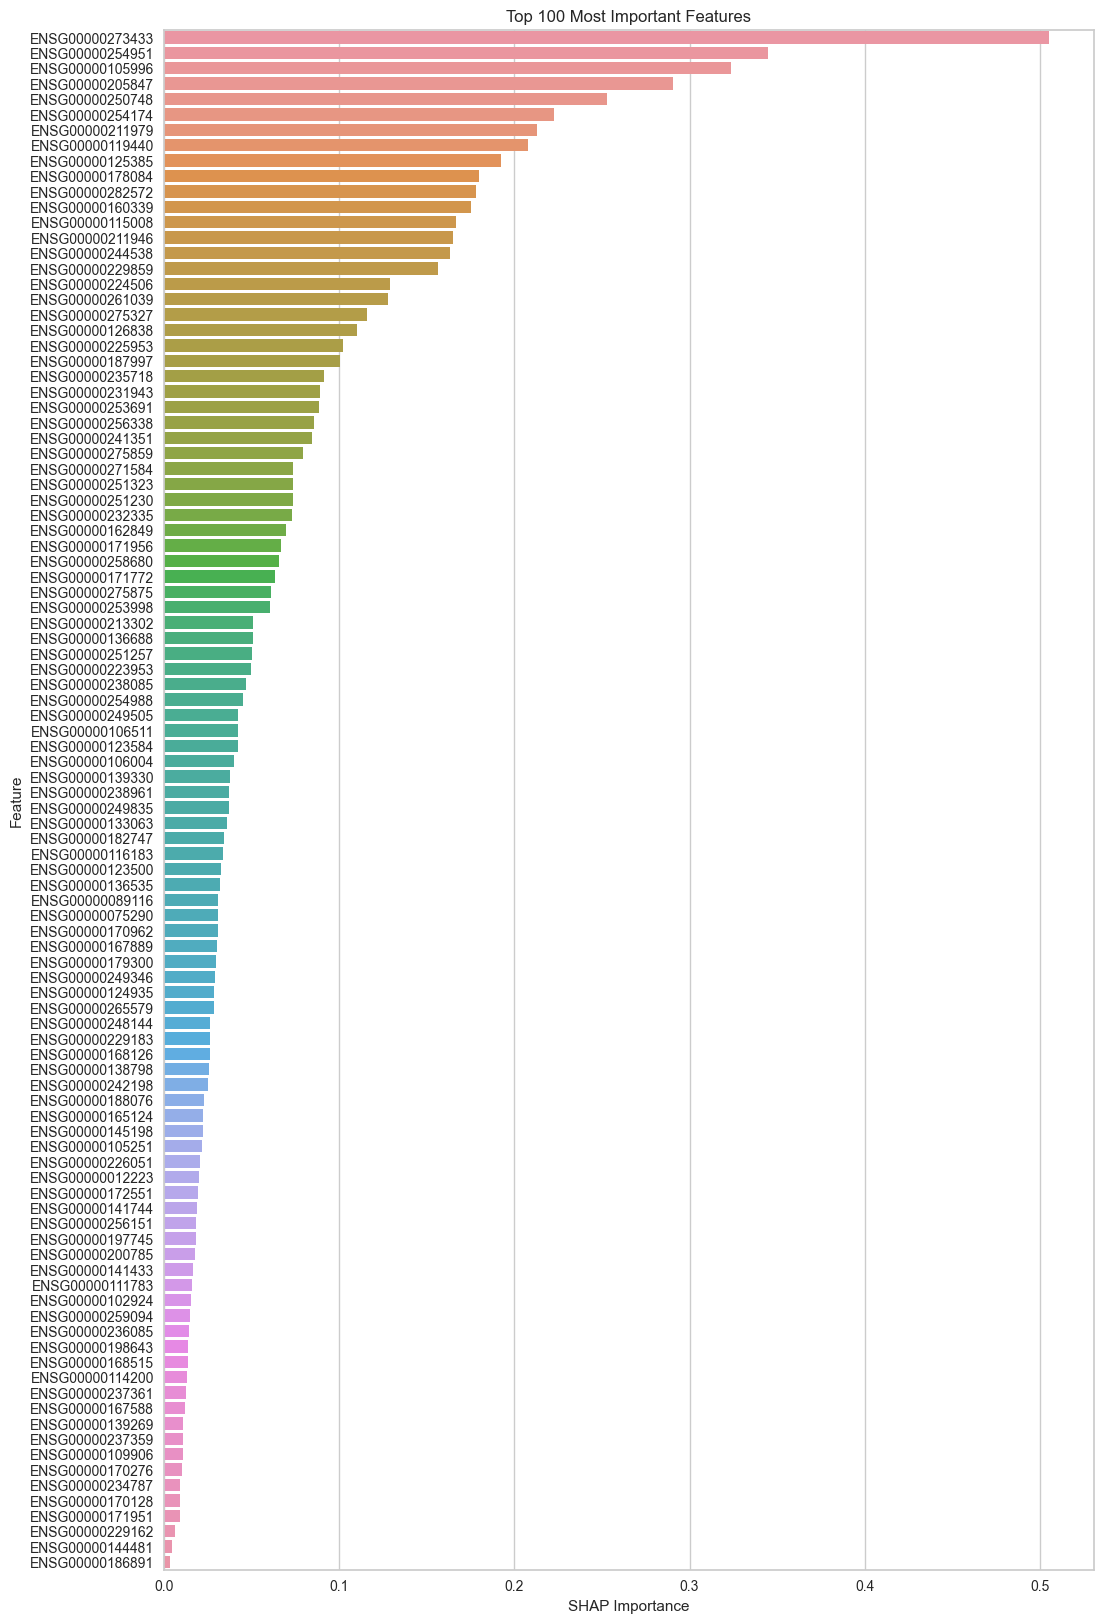

In [34]:
# SHAP summary plots 
explainer = shap.Explainer(best_model, X_train) 
shap_values = explainer(X_test) 
plt.figure(figsize=(15, 10)) # Increase the plot size 
shap.summary_plot(shap_values, X_test) # Determine the top 100 most important features based on SHAP values 
shap_importances = np.abs(shap_values.values).mean(axis=0) 
shap_importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': shap_importances}) 
shap_importance_df = shap_importance_df.sort_values(by='importance', ascending=False).head(100) # Save the top 100 features to a CSV file 
shap_importance_df.to_csv('C:\\Users\\MHC PC\\Desktop\\gene expresion\\9-1403\\top_100_shap_features.csv', index=False) 
print(f"Top 100 most important features saved to 'top_100_shap_features.csv'") # Plot top 100 most important features 
plt.figure(figsize=(12, 20)) # Increase the plot size 
sns.barplot(x='importance', y='feature', data=shap_importance_df) 
plt.title('Top 100 Most Important Features') 
plt.xlabel('SHAP Importance') 
plt.ylabel('Feature')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from pycaret.classification import *
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from catboost import CatBoostClassifier

# Step 1: Prepare features and target variable
X_resampled = data_filtered.drop(['stage_group'], axis=1)  # Drop target variable
y_resampled = data_filtered['stage_group']

# Normalize the features
scaler = StandardScaler()
X_resampled = scaler.fit_transform(X_resampled)
X_resampled = pd.DataFrame(X_resampled, columns=data_filtered.drop(['stage_group'], axis=1).columns)

# Initialize LabelEncoder
label_encoder = LabelEncoder()
y_resampled = label_encoder.fit_transform(y_resampled)

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y_resampled)

# Step 3: Perform SMOTE-Tomek on the training set
smote_tomek = SMOTETomek(random_state=123)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

# Convert y_resampled back to Series
y_resampled = pd.Series(y_resampled, name='stage_group')

# Step 4: Setup PyCaret with the resampled training data
exp_name = setup(data=pd.concat([X_resampled, y_resampled], axis=1),
                 target='stage_group',
                 session_id=123,
                 fix_imbalance=False,
                 remove_outliers=True,
                 fold_shuffle=True)

# Step 5: Hyperparameter tuning for CatBoost
catboost_model = CatBoostClassifier(random_state=123, verbose=0)

# Define the parameter grid for CatBoost
param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'l2_leaf_reg': [3, 5, 7]
}

# Set up the grid search with cross-validation
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid,
                           scoring='roc_auc', cv=5, verbose=2, n_jobs=-1)

# Fit the grid search on the resampled training data
grid_search.fit(X_resampled, y_resampled)

# Best parameters
best_catboost = grid_search.best_estimator_

# Step 6: Prepare test data for predictions
y_test_series = pd.Series(y_test, name='stage_group')  # Convert y_test to a Series
test_data = pd.concat([X_test.reset_index(drop=True), y_test_series.reset_index(drop=True)], axis=1)

# Step 7: Predict on the test data
predictions = predict_model(best_catboost, data=test_data)

# Step 8: Get the predicted probabilities for the positive class
y_pred_proba = predictions['prediction_score']
y_pred = predictions['prediction_label']

# Step 10: Calculate evaluation metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Step 11: Display the results
print(f"AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Step 12: Evaluate the best model
evaluate_model(best_catboost)
interpret_model(best_catboost, plot='summary')

# Step 13: Plot model performance
plot_model(best_catboost, plot='auc')
plot_model(best_catboost, plot='confusion_matrix', plot_kwargs={'percent': True})
plot_model(best_catboost, plot='feature')

# Step 14: Save the best model
save_model(best_catboost, '/content/drive/MyDrive/gene_expression/clinical and stage/based_stage_saved_best_model')

# Step 15: Extract feature importances
feature_importances = best_catboost.get_feature_importance()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': X_resampled.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Get the top 100 features
top_100_features = feature_importance_df.head(100)

# Save top 100 features to a CSV file
top_100_features.to_csv('/content/drive/MyDrive/gene_expression/clinical and stage/based_stage_top_100_features.csv', index=False)
